### MÉTODO 2 (ROI + KMEANS)

In [76]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================
import os                     
import time                   
import csv                   
import cv2                    
import numpy as np            
from glob import glob         
import matplotlib.pyplot as plt  

#### DEFINICIÓN DE RUTAS

In [77]:
TRAIN_DIR = r"H:\MaestriaUIDE\final_1\Data_2"   # Imágenes para entrenamiento
TEST_DIR  = r"H:\MaestriaUIDE\final_1\Data"     # Imágenes para prueba
OUT_DIR   = r"H:\MaestriaUIDE\final_1\out_kmeans_metodo2"  # Resultados

os.makedirs(OUT_DIR, exist_ok=True)

#### PARÁMETROS DEL EXPERIMENTO

In [78]:
K = 4                     # Número de clusters
MAX_SAMPLES = 500_000     # Máximo de píxeles ROI totales
PER_IMAGE_CAP = 8_000     # Máximo de píxeles ROI por imagen
SEED = 42                 # Reproducibilidad

KMEANS_ATTEMPTS = 3
KMEANS_MAXITER = 40
KMEANS_EPS = 0.5

SHOW_EXAMPLES = 2         # Número de imágenes de ejemplo a mostrar

#### LISTAR IMÁGENES

In [79]:
def list_imgs(folder):
    """
    Retorna lista ordenada de imágenes compatibles.
    """
    return sorted(
        glob(os.path.join(folder, "*.tif")) +
        glob(os.path.join(folder, "*.tiff")) +
        glob(os.path.join(folder, "*.png")) +
        glob(os.path.join(folder, "*.jpg")) +
        glob(os.path.join(folder, "*.jpeg"))
    )


#### ASEGURAR IMAGEN EN GRAYSCALE UINT8

In [80]:
def ensure_uint8_gray(img):
    """
    Convierte imagen a escala de grises 8 bits.
    Garantiza formato adecuado para OpenCV.
    """
    if img is None:
        return None
    
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if img.dtype != np.uint8:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    return img

EXTRACCIÓN ROI (MÉTODO 2)

In [81]:
def roi_mask_seq_method2(img_in):
    """
    Extrae la Región de Interés (ROI) usando:
    - Suavizado Gaussiano
    - Canny adaptativo
    - Morfología
    - Selección del contorno mayor
    - Limpieza por componente conexa dominante
    """

    img = ensure_uint8_gray(img_in)
    if img is None:
        return None

    # 1️⃣ Suavizado para reducción de ruido
    blurred = cv2.GaussianBlur(img, (5, 5), 0)

    # 2️⃣ Cálculo automático de umbrales Canny
    v = np.median(blurred)
    sigma = 0.10
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    edges = cv2.Canny(blurred, lower, upper)

    # 3️⃣ Operaciones morfológicas
    kernel = np.ones((5, 5), np.uint8)
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    dilated = cv2.dilate(closed, kernel, iterations=2)

    # 4️⃣ Crear máscara vacía
    mask_seq = np.zeros_like(img, dtype=np.uint8)

    # 5️⃣ Encontrar contornos externos
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest = max(contours, key=cv2.contourArea)
        cv2.drawContours(mask_seq, [largest], -1, 255, -1)

    # 6️⃣ Asegurar componente conexa dominante (robustez adicional)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_seq, 8)

    if num_labels > 1:
        largest_component = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        clean_mask = np.zeros_like(mask_seq)
        clean_mask[labels == largest_component] = 255
        mask_seq = clean_mask

    return mask_seq

#### MUESTREO INTELIGENTE DE PÍXELES ROI

In [82]:
def collect_roi_pixels_stream(train_paths, max_samples, per_image_cap, seed=42):
    """
    Extrae píxeles SOLO de la ROI con control de cantidad máxima.
    Permite limitar el número total de muestras para optimización.
    """
    rng = np.random.default_rng(seed)
    samples = []
    total = 0

    for p in train_paths:
        img = cv2.imread(p, 0)
        if img is None:
            continue

        mask = roi_mask_seq_method2(img)
        if mask is None:
            continue

        vals = img[mask > 0].astype(np.float32)
        if vals.size == 0:
            continue

        take = min(per_image_cap, vals.size, max_samples - total)
        if take <= 0:
            break

        idx = rng.choice(vals.size, size=take, replace=False)
        samples.append(vals[idx])
        total += take

        if total >= max_samples:
            break

    if total == 0:
        raise ValueError("No se obtuvieron píxeles ROI.")

    return np.concatenate(samples).reshape(-1, 1)

#### ENTRENAMIENTO KMEANS 1D

In [83]:
def train_kmeans_1d(pixels, k):
    """
    Aplica K-means sobre intensidades escala de grises.
    """
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
                KMEANS_MAXITER, KMEANS_EPS)

    compactness, labels, centers = cv2.kmeans(
        pixels, K, None, criteria, KMEANS_ATTEMPTS,
        cv2.KMEANS_PP_CENTERS
    )

    labels = labels.flatten()
    centers = centers.flatten()

    stats = []
    for i in range(k):
        v = pixels[labels == i]
        if v.size == 0:
            continue
        stats.append((i, float(centers[i]), float(v.min()), float(v.max())))
    stats.sort(key=lambda x: x[1])  # orden por centro
    return float(compactness), centers.astype(np.float32), stats

    

In [84]:
def assign_clusters_roi(img_gray, mask, centers):
    """
    Asigna cada píxel de la Región de Interés (ROI)
    al cluster cuyo centro esté más cercano.

    Parámetros:
    img_gray : imagen en escala de grises
    mask     : máscara binaria ROI
    centers  : centros obtenidos del K-means

    Retorna:
    Imagen donde solo la ROI tiene valores de cluster.
    """

    # Crear imagen de salida inicializada en 0
    out = np.zeros_like(img_gray, dtype=np.uint8)

    # Obtener coordenadas donde la máscara es blanca
    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return out  # Si no hay ROI, retornar imagen vacía

    # Extraer intensidades solo en ROI
    vals = img_gray[ys, xs].astype(np.float32)

    # Calcular distancia absoluta a cada centro
    d = np.abs(vals.reshape(-1, 1) - centers.reshape(1, -1))

    # Asignar cluster más cercano
    labels = np.argmin(d, axis=1).astype(np.uint8)

    # Escalar etiquetas para visualización
    scale = max(1, int(255 / (len(centers) + 1)))
    out[ys, xs] = (labels + 1) * scale

    return out

#### EJECUCIÓN PRINCIPAL

In [85]:
train_paths = list_imgs(TRAIN_DIR)
test_paths  = list_imgs(TEST_DIR)

print("Imágenes Train:", len(train_paths))
print("Imágenes Test:", len(test_paths))

if not train_paths:
    raise ValueError("TRAIN_DIR no tiene imágenes.")
if not test_paths:
    raise ValueError("TEST_DIR no tiene imágenes.")


Imágenes Train: 1
Imágenes Test: 350


#### ENTRENAMIENTO

In [86]:
t0 = time.time()

print("\n[1/4] Muestreando pixeles ROI (mask_seq método 2) del train...")

pixels = collect_roi_pixels_stream(train_paths, MAX_SAMPLES, PER_IMAGE_CAP, SEED)
print("Total píxeles ROI:", pixels.shape[0])

print("  Tiempo sampling:", round(time.time() - t0, 2), "s")

t1 = time.time()
print("\n[2/4] Entrenando K-means SOLO en ROI...")

compactness, centers, stats = train_kmeans_1d(pixels, K)
print("  Compactness:", round(compactness, 2))
print("  Tiempo kmeans:", round(time.time() - t1, 2), "s")


tiempo_entrenamiento = round(time.time() - t0, 2)
print("Tiempo entrenamiento:", tiempo_entrenamiento, "segundos")


[1/4] Muestreando pixeles ROI (mask_seq método 2) del train...
Total píxeles ROI: 6315
  Tiempo sampling: 0.01 s

[2/4] Entrenando K-means SOLO en ROI...
  Compactness: 53186.0
  Tiempo kmeans: 0.01 s
Tiempo entrenamiento: 0.02 segundos


#### VISUALIZACIÓN 

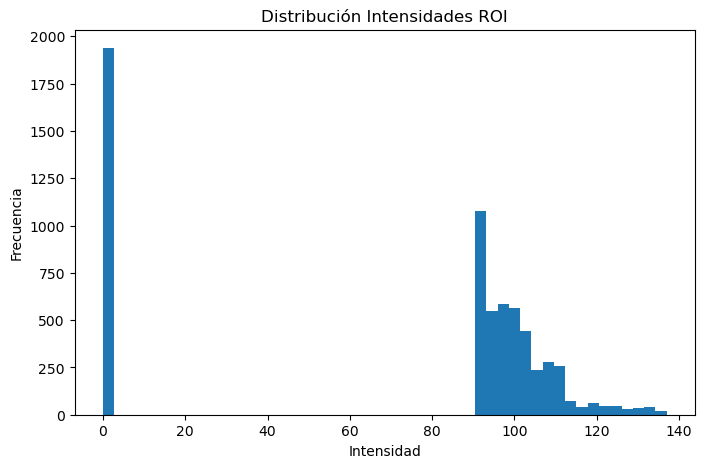

In [87]:
# Histograma de intensidades ROI
plt.figure(figsize=(8,5))
plt.hist(pixels, bins=50)
plt.title("Distribución Intensidades ROI")
plt.xlabel("Intensidad")
plt.ylabel("Frecuencia")
plt.show()

### TABLA COMPARATIVA

In [88]:
# Tabla tipo tu ejemplo
print("\nCluster | Center | Min | Max")
print("-" * 30)
for cid, c, mn, mx in stats:
    print(f"{cid:<7} | {c:>6.2f} | {mn:>3.0f} | {mx:>3.0f}")

# Exportar CSV
csv_path = os.path.join(OUT_DIR, f"clusters_metodo2_maskseq_K{K}.csv")
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["cluster_id", "center", "min", "max"])
    for cid, c, mn, mx in stats:
        w.writerow([cid, round(c, 3), round(mn, 3), round(mx, 3)])
print("\n[3/4] CSV guardado:", csv_path)


Cluster | Center | Min | Max
------------------------------
0       |   0.00 |   0 |   0
1       |  94.77 |  91 | 100
3       | 105.98 | 101 | 115
2       | 124.74 | 116 | 137

[3/4] CSV guardado: H:\MaestriaUIDE\final_1\out_kmeans_metodo2\clusters_metodo2_maskseq_K4.csv


#### APLICACIÓN A TEST


[3] Aplicando al conjunto TEST...


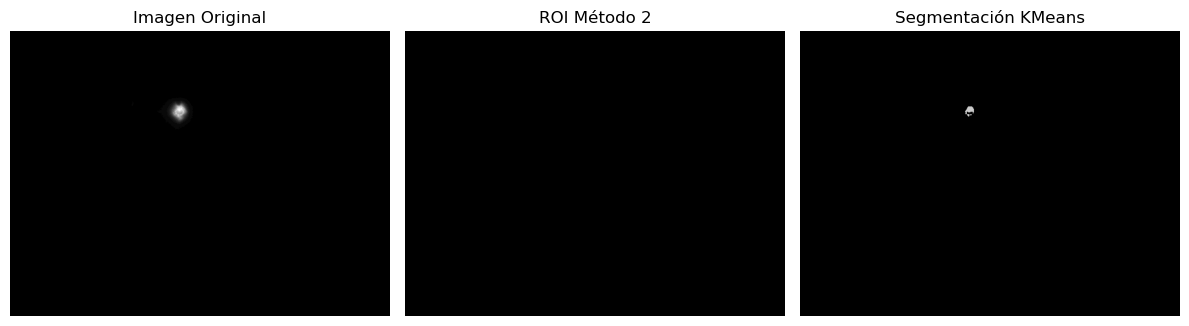

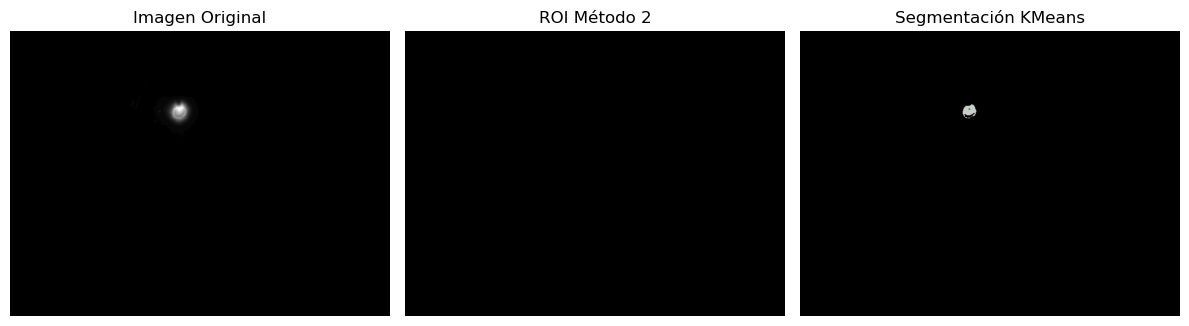

Tiempo aplicación TEST: 1.22 segundos

✅ Terminado. Resultados en: H:\MaestriaUIDE\final_1\out_kmeans_metodo2
Tiempo total: 81.14 s


In [90]:
print("\n[3] Aplicando al conjunto TEST...")

tiempo_test_inicio = time.time()

shown = 0

for i, p in enumerate(test_paths[:SHOW_EXAMPLES]):
    
    img = cv2.imread(p, 0)
    
    if img is None:
        continue

    mask = roi_mask_seq_method2(img)
    roi_only = cv2.bitwise_and(img, img, mask=mask)
    clusters_map = assign_clusters_roi(img, mask, centers)

    base = os.path.splitext(os.path.basename(p))[0]
    cv2.imwrite(os.path.join(OUT_DIR, f"{base}_roi.png"), roi_only)
    cv2.imwrite(os.path.join(OUT_DIR, f"{base}_clusters_K{K}.png"), clusters_map)

    # Clasificación por distancia mínima
    vals = img.astype(np.float32)
    d = np.abs(vals.reshape(-1,1) - centers.reshape(1,-1))
    labels = np.argmin(d, axis=1)
    cluster_img = labels.reshape(img.shape)

    if shown < SHOW_EXAMPLES:
        shown += 1
        # Visualización comparativa
        plt.figure(figsize=(12,4))
        
        plt.subplot(1,3,1)
        plt.imshow(img, cmap='gray')
        plt.title("Imagen Original")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(mask, cmap='gray')
        plt.title("ROI Método 2")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(cluster_img, cmap='nipy_spectral')
        plt.title("Segmentación KMeans")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

tiempo_test = round(time.time() - tiempo_test_inicio,2)

print("Tiempo aplicación TEST:", tiempo_test, "segundos")
print("\n✅ Terminado. Resultados en:", OUT_DIR)
print("Tiempo total:", round(time.time() - t0, 2), "s")

#### RESUMEN

In [91]:
print("\n================ RESULTADOS FINALES ================")
print("Tiempo entrenamiento:", tiempo_entrenamiento)
print("Tiempo aplicación test:", tiempo_test)
print("Compactness final:", round(compactness,2))
print("===================================================")


================ RESULTADOS FINALES ================
Tiempo entrenamiento: 0.02
Tiempo aplicación test: 1.22
Compactness final: 53186.0
